In [8]:
import pandas as pd 
import numpy as np

In [2]:
!kaggle datasets list

ref                                                                 title                                                size  lastUpdated          downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
rabieelkharoua/students-performance-dataset                         📚 Students Performance Dataset 📚                     66KB  2024-06-12 23:09:20          13859        287  1.0              
nelgiriyewithana/most-streamed-spotify-songs-2024                   Most Streamed Spotify Songs 2024                    496KB  2024-06-15 18:50:51          10445        216  1.0              
ihelon/coffee-sales                                                 Coffee Sales                                         10KB  2024-07-03 20:04:43           2745         55  1.0              
tarktunataalt/2023-global-country-develo

In [10]:
!kaggle datasets download kapturovalexander/food-orders


Dataset URL: https://www.kaggle.com/datasets/kapturovalexander/food-orders
License(s): CC0-1.0




  0%|          | 0.00/846k [00:00<?, ?B/s]
100%|██████████| 846k/846k [00:02<00:00, 364kB/s]
100%|██████████| 846k/846k [00:02<00:00, 364kB/s]


In [ ]:
!unzip food-orders

: 

In [66]:
import pandas as pd
df =  pd.read_csv("SAT__College_Board__2010_School_Level_Results_20240506.csv")
df

,DBN,School Name,Number of Test Takers,Critical Reading Mean,Mathematics Mean,Writing Mean
0,01M292,Henry Street School for International Studies,31.0,391.0,425.0,385.0
1,01M448,University Neighborhood High School,60.0,394.0,419.0,387.0
2,01M450,East Side Community High School,69.0,418.0,431.0,402.0
3,01M458,SATELLITE ACADEMY FORSYTH ST,26.0,385.0,370.0,378.0
4,01M509,CMSP HIGH SCHOOL,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
455,75R025,South Richmond High School,10.0,407.0,421.0,400.0
456,75X012,PS12X LEWIS AND CLARK SCHOOL,NaN,NaN,NaN,NaN
457,75X754,P754 X - Jeffrey M. Rapport School for Career ...,NaN,NaN,NaN,NaN
458,76K460,John Jay High School,9.0,390.0,381.0,398.0


In [67]:
df['DBN'].is_unique

False

In [68]:
df.set_index('School Name')

,DBN,Number of Test Takers,Critical Reading Mean,Mathematics Mean,Writing Mean
School Name,,,,,
Henry Street School for International Studies,01M292,31.0,391.0,425.0,385.0
University Neighborhood High School,01M448,60.0,394.0,419.0,387.0
East Side Community High School,01M450,69.0,418.0,431.0,402.0
SATELLITE ACADEMY FORSYTH ST,01M458,26.0,385.0,370.0,378.0
CMSP HIGH SCHOOL,01M509,NaN,NaN,NaN,NaN
...,...,...,...,...,...
South Richmond High School,75R025,10.0,407.0,421.0,400.0
PS12X LEWIS AND CLARK SCHOOL,75X012,NaN,NaN,NaN,NaN
P754 X - Jeffrey M. Rapport School for Career Devt,75X754,NaN,NaN,NaN,NaN


In [69]:
to_drop = ['DBN']
df = df.drop(to_drop, axis=1)

In [70]:
df.head()

,School Name,Number of Test Takers,Critical Reading Mean,Mathematics Mean,Writing Mean
0,Henry Street School for International Studies,31.0,391.0,425.0,385.0
1,University Neighborhood High School,60.0,394.0,419.0,387.0
2,East Side Community High School,69.0,418.0,431.0,402.0
3,SATELLITE ACADEMY FORSYTH ST,26.0,385.0,370.0,378.0
4,CMSP HIGH SCHOOL,NaN,NaN,NaN,NaN


In [71]:
df.isna()

,School Name,Number of Test Takers,Critical Reading Mean,Mathematics Mean,Writing Mean
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,True,True,True,True
...,...,...,...,...,...
455,False,False,False,False,False
456,False,True,True,True,True
457,False,True,True,True,True
458,False,False,False,False,False


In [73]:
df.dropna(inplace=True)

In [74]:
df

,School Name,Number of Test Takers,Critical Reading Mean,Mathematics Mean,Writing Mean
0,Henry Street School for International Studies,31.0,391.0,425.0,385.0
1,University Neighborhood High School,60.0,394.0,419.0,387.0
2,East Side Community High School,69.0,418.0,431.0,402.0
3,SATELLITE ACADEMY FORSYTH ST,26.0,385.0,370.0,378.0
5,Lower East Side Preparatory High School,154.0,314.0,532.0,314.0
...,...,...,...,...,...
448,ALL CITY LEADERSHIP SECONDARY,29.0,394.0,420.0,395.0
449,Bushwick Leaders High School for Academic Excel,30.0,357.0,345.0,351.0
455,South Richmond High School,10.0,407.0,421.0,400.0
458,John Jay High School,9.0,390.0,381.0,398.0


In [85]:
df['School Name'] = pd.to_numeric(df['School Name'], errors='coerce')

In [97]:

df_Noschool = df

In [101]:
dfnoshoolfix = df_Noschool.drop(columns=['School Name'])


In [104]:
dfnoshoolfix

,Number of Test Takers,Critical Reading Mean,Mathematics Mean,Writing Mean
0,31.0,391.0,425.0,385.0
1,60.0,394.0,419.0,387.0
2,69.0,418.0,431.0,402.0
3,26.0,385.0,370.0,378.0
5,154.0,314.0,532.0,314.0
...,...,...,...,...
448,29.0,394.0,420.0,395.0
449,30.0,357.0,345.0,351.0
455,10.0,407.0,421.0,400.0
458,9.0,390.0,381.0,398.0


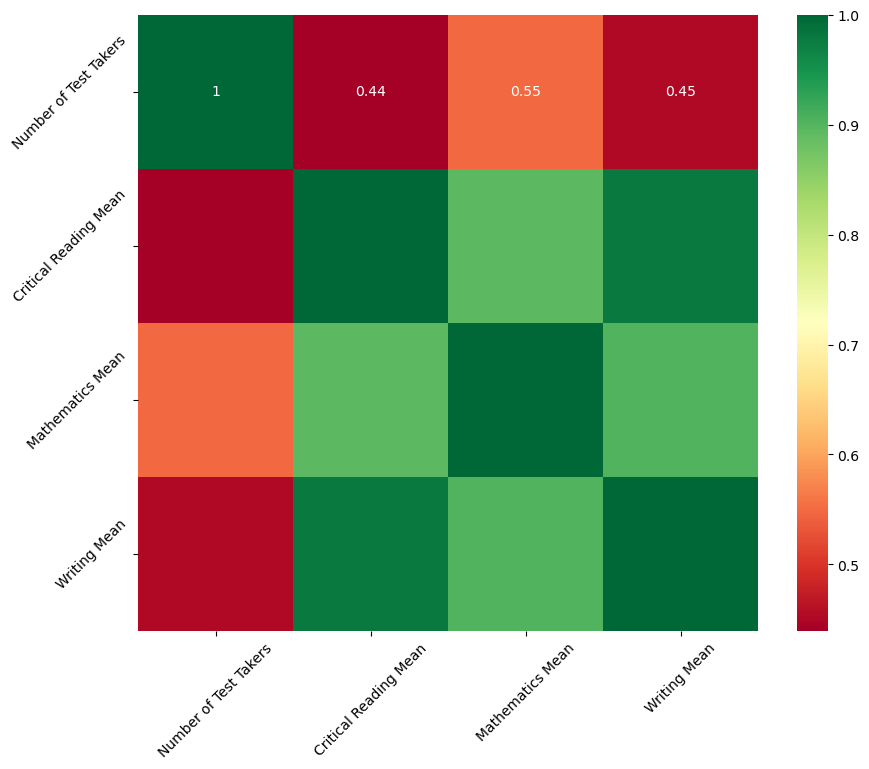

In [105]:
import pandas as pd
import numpy as np 
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sn

# Assuming df is your DataFrame containing your data
corrmat = dfnoshoolfix.corr()
top_corr_features = corrmat.index

plt.figure(figsize=(10, 8))
g = sn.heatmap(dfnoshoolfix[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.yticks(rotation=45)  # Rotate y-axis labels for better readability
plt.show()

